## .

## Dataclass functions

In [ ]:
from dataclasses import dataclass
import numpy as np
np.set_printoptions(linewidth=100000)

@dataclass
class ResonancesTerm:
    """  """
    a: int
    b: int
    c: int = None
    states: dict = None
    
    def data(self, ws, F):
        self.ws = ws
        self.F = F
        # print(ws[0].shape)
        # print(ws[1].shape)
    
        
    def value(self, resonances):
        
        self.resonance1 = Resonance(resonances[0], 2, self.states, self.ws).value()
        # print(self.resonance1)
        
        self.resonance2 = Resonance(resonances[1], 1, self.states, self.ws).value()
        # print(self.resonance2)
        res = 1 / self.resonance1 / self.resonance2
        
        return res

@dataclass
class W_ab_c:
    """w_{a+b}, w_{a+b+c}"""
    combination: tuple
    states: dict
    #Delta: np.array
    
    def value(self):
        res = 0.
        index = ""
        
        for i in self.combination:
            if i=="0":
                res += 0.
            else:
                res += self.states[str(i)]
            
            if len(self.combination)>1: index += str(i)
        
        return res+self.states[''.join(sorted(index))]

@dataclass
class Resonance:
    """w_{m, n}^{[-12]}, w_{m, n}^{[-1]}, w_{m, n}"""
    mn: tuple # = ((a, b,), (0, a))
    
    typeR: int  # superscript
    states: dict
    ws: tuple
    
    def value(self):
        w_m = W_ab_c(self.mn[0], self.states).value()
        w_n = W_ab_c(self.mn[1], self.states).value()
        Gamma = 10**(-12)
        # print("-------------\nparts")
        # print(w_m, w_n, self.ws[0], self.ws[1])
        
        if self.typeR == 1:
            return w_m - w_n + self.ws[0] - 1j*Gamma
        elif self.typeR == 2:
            return w_m - w_n + self.ws[0] + self.ws[1] - 1j*Gamma
        elif self.typeR == 0:
            return w_m - w_n
        

# @dataclass
# class Gamma_mn:
#     """Final sum"""

### Testing functions

In [ ]:
# states = {'':0., '0':2, '1':4, '00':4, '11': 8, '01':6}
states = {'0':2, '1':4} #, '00':4, '11': 8, '01':6}
w1, w2 = (np.linspace(4, 8, 3), np.linspace(4, 8, 3))
ws_freqs = np.meshgrid(w1, w2)
# print(ws_freqs)

F = np.zeros((2, 2, 2))
for i in F:
    for j in i: 
        j = 1.

a, b = 0, 0
resonances = ((a, b,), (a,)), (("0",), (a,))

d = ResonancesTerm(a=a, b=b, c=None, states=states)
d.data(ws=ws_freqs, F=F)
final = d.value(resonances=resonances)

# print(final)
Nfund = 2
# gamma_mn(Nfund, w1, w2, states, F)

## Plotting function

In [113]:
%matplotlib widget
from ipywidgets import *
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import numpy as np
np.set_printoptions(linewidth=100000)


def rendering2D(X, Y, Z):
    plt.clf()

    # PLOTTING
    fig, ax = plt.subplots()
    fig.set_size_inches(11, 9)

    # print(X)
    # print(Z)

    ax.set_xlabel('w1', fontsize=18)

    cp = ax.contourf(X, Y, Z)
    cb = fig.colorbar(cp)

    # plt.xticks(np.linspace(0, 120, 10))
    ax.set_xticks(np.linspace(min(X.flatten()), max(X.flatten()), 10))
    ax.set_yticks(np.linspace(min(Y.flatten()), max(Y.flatten()), 10))

    plt.show()

## $\gamma^{[0, 1]}$ - electical anharmonicity, $\gamma^{[0, 1]}$ - mechanical anharmonicity

In [135]:
t1el = lambda w, w1, w2, Delta, Gamma, a, b: \
        1 / ((w[str(a)]+w[str(b)]-Delta[''.join(sorted(str(a)+str(b)))])-w[str(a)]+w1-w2-1j*Gamma) / (0.-w[str(a)]+w1-1j*Gamma)

t2el = lambda w, w1, w2, Delta, Gamma, a, b: \
        1 / (w[str(b)]-w[str(a)]+w1-w2-1j*Gamma) / (0.-w[str(a)]+w1-1j*Gamma)

t1mech = lambda w, w1, w2, Delta, Gamma, a, b, c: \
        1 / ((w[str(a)]+ w[str(b)]-Delta[''.join(sorted(str(a)+str(b)))])-w[str(a)]+w1-w2-1j*Gamma) / (0.-w[str(a)]+w1-1j*Gamma) * \
       (1 / ((w[str(a)]+ w[str(b)]+w[str(c)]-Delta[''.join(sorted(str(a)+str(b)+str(c)))])-0.+0.0001) \
      + 1 / ( w[str(c)]-(w[str(a)]+w[str(b)]-Delta[''.join(sorted(str(a)+str(b)))]) +0.0001))

def gamma_mn(Nfund, w1, w2, states, F, Delta):
    w1w1, w2w2 = np.meshgrid(w1, w2)
    total_sum_el = np.zeros(w1w1.shape, dtype=('complex128'))
    total_sum_mech = np.zeros(w1w1.shape, dtype=('complex128'))
    
    Gamma = 10**(-12)
    
    for a in range(Nfund):
        for b in range(Nfund):
            # print(a,b, states[str(a)], states[str(a)]+states[str(b)])
            
            prefac_el = 1 /states[str(a)]/states[str(b)]
            
            averg_el = 1
            
            # electrical
            total_sum_el += prefac_el * averg_el * t1el(states, w1w1, w2w2, Delta, Gamma, a, b)
            # total_sum_el += prefac_el * t2el(states, w1w1, w2w2, Delta, Gamma, a, b)
            
            for c in range(Nfund):
                # print('here', a, b, c)
                averg_mech = 1
                prefac_mech = 1 /states[str(a)]/states[str(b)]/states[str(c)]
                
                # mechanical
                # total_sum_mech += prefac_mech * averg_mech * t1mech(states, w1w1, w2w2, Delta, Gamma, a, b, c)
                pass
    
    return w1w1, w2w2, (total_sum_el/24.-total_sum_mech/48.)

In [138]:
F = np.zeros((2, 2, 2))
for i in F:
    for j in i: 
        j = 1.
        
Delta = {'00': 40, '11': 60, '22':100, '01': 50, '12': 80, '02': 70, 
         '000':60, '001':70, '011':80, '111':90, '002':90, '022':120, '012':100, '112':110, '122':120, '222':150}
for i in Delta: Delta[i]=0.

states = {'0':20, '1':30
           , '2':50
         }

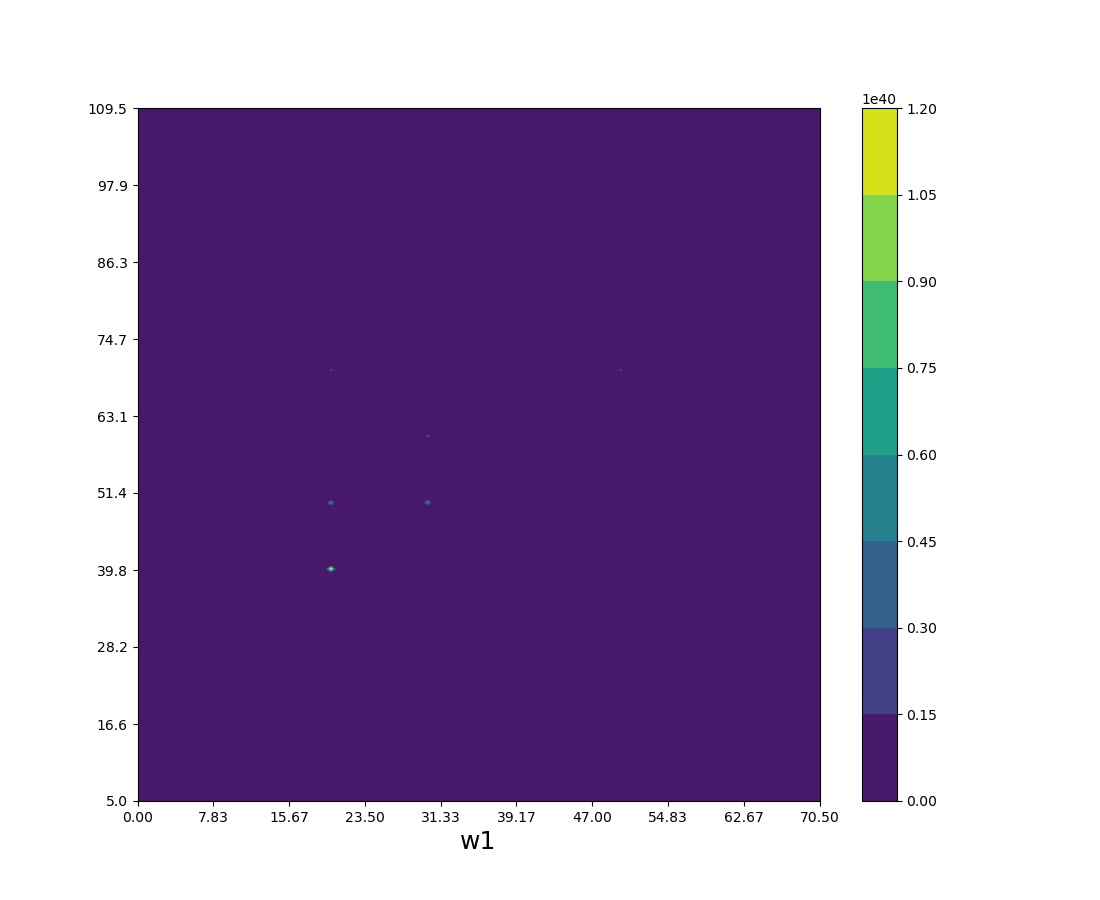

In [139]:
# states = {'':0., '0':30, '1':40, '00':60, '11': 80, '01':70}
Nfund = len(states)
# aa, bb, cc, dd = 0, 71, 15, 110
w1 = np.arange(0., 71, 0.5)
w2 = np.arange(5, 110, 0.5)

X, Y, zz = gamma_mn(Nfund, w1, w2, states, F, Delta)
Z = abs(zz)**2

rendering2D(X, Y, Z)